# Проект. Исследование стартапов на исторических данных

## Введение

**Автор**: Каримов Газиз

**Дата**: 30.07.2026

## Цели и задачи

**Цель**: определить наиболее подходящую область и стратегию инвестирования в 2015 году

**Задачи**:

1. Изучить имеющиеся данные о направлениях и видах инвестирования;
2. Провести предобработку данных;
3. Провести исследовательский анализ данных;
4. Подвести итоговые выводы и дать рекомендации.

## Данные

Для исследования будут использованы данные из двух датасетов:

- `/datasets/cb_investments.zip` : содержит информацию о компаниях и состоявшемся финансировании:
- `/datasets/cb_returns.csv` : содержит информацию об объёмах возвратов по годам и типам финансирования в миллионах долларов

### Описание датасета `cb_investments`:
Датасет содержит следующие поля
- name — название компании;
- homepage_url — ссылка на сайт компании;
- category_list — категории, в которых работает компания. Указываются через |;
- market — основной рынок или отрасль компании;
- funding_total_usd — общий объём привлечённых инвестиций в долларах США;
- status — текущий статус компании, например, operating, closed и так далее;
- country_code — код страны, например USA;
- state_code — код штата или региона, например CA;
- region — регион, например SF Bay Area;
- city — город, в котором расположена компания;
- funding_rounds — общее число раундов финансирования;
- participants — число участников в раундах финансирования;
- founded_at — дата основания компании;
- founded_month — месяц основания в формате YYYY-MM;
- founded_quarter — квартал основания в формате YYYY-QN;
- founded_year — год основания;
- first_funding_at — дата первого финансирования;
- mid_funding_at — дата среднего по времени раунда финансирования;
- last_funding_at — дата последнего финансирования;
- seed — сумма инвестиций на посевной стадии;
- venture — сумма венчурных инвестиций;
- equity_crowdfunding — сумма, привлечённая через долевой краудфандинг;
- undisclosed — сумма финансирования нераскрытого типа;
- convertible_note — сумма инвестиций через конвертируемые займы;
- debt_financing — сумма долгового финансирования;
- angel — сумма инвестиций от бизнес-ангелов;
- grant — сумма полученных грантов;
- private_equity — сумма инвестиций в виде прямых (частных) вложений;
- post_ipo_equity — сумма финансирования после IPO;
- post_ipo_debt — сумма долгового финансирования после IPO;
- secondary_market — сумма сделок на вторичном рынке;
- product_crowdfunding — сумма, привлечённая через продуктовый краудфандинг;
- round_A — round_H — сумма инвестиций в соответствующем раунде.


### Описание датасета `cb_returns`:
Датасет содержит следующие поля:
- year — год возврата средств;
- seed — сумма возвратов от посевных инвестиций;
- venture — сумма возвратов от венчурных инвестиций;
- equity_crowdfunding — сумма, возвращённая по долевому краудфандингу;
- undisclosed — сумма возвратов нераскрытого типа;
- convertible_note — сумма возвратов через конвертируемые займы;
- debt_financing — сумма возвратов от долгового финансирования;
- angel — сумма возвратов бизнес-ангелам;
- grant — сумма возвратов по грантам;
- private_equity — сумма возвратов прямых (частных) вложений;
- post_ipo_equity — сумма возвратов от IPO;
- post_ipo_debt — сумма возвратов от долгового IPO;
- secondary_market — сумма возвратов от сделок на вторичном рынке;
- product_crowdfunding — сумма возвратов по продуктовому краудфандингу.

## Содержимое проекта
1. Знакомство с данными и первичный анализ
2. Предобработка данных (работа с пропусками, дубликатами и типами данных)
3. Инжиниринг признаков
4. Работа с выбросами и анализ
5. Анализ динамики данных по годам
6. Выводы и рекомендации

## Знакомство с данными: загрузка и предобработка

In [1]:
# Загружаем необходимые библиотеки
import pandas as pd 

# Библиотеки для визуализаций
import matplotlib.pyplot as plt
import seaborn as sns


### Загружаем данные в тетрадку:

In [2]:
invest_df=pd.read_csv('../../Data (csv)/Файлы проекта 2 модуля/cb_investments.csv',sep=';',low_memory=False)


In [3]:
returns_df=pd.read_csv('../../Data (csv)/Файлы проекта 2 модуля/cb_returns.csv')


Для датасета `cb_returns` поле `year` сделаем индексом

In [4]:
returns_df.set_index('year',inplace=True)

### Первичный анализ данных

Знакомимся с данными датасета `cb_investments`:

In [5]:
# Выводим общую информацию о датасете
invest_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [6]:
# Выведем первые 5 строк
invest_df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


После первичного анализа датасета `cb_investments` можно сделать следующие выводы:

- датасет  содержит 54294 строк и 40 столбцов;
- в каждом столбце наблюдаются пропуски;
- не во всех полях типы данных соответствуют содержанию согласно описанию: например, в столбце `funding_total_usd` содержится информация об объемах инвестиций в долларах, т.е. тип данных должен быть либо int либо float, а не object;
- в названиях нескольких столбцов наблюдаются отступы и заглавные буквы, что будет мешать в дальнейшей работе. Таким образом, необходимо будет привести названия к единому стилю snake_case.

Знакомимся с данными датасета `cb_returns`:

In [7]:
# Выведем общую информацю о датасете
returns_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15 entries, 2000 to 2014
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   seed                  15 non-null     float64
 1   venture               15 non-null     float64
 2   equity_crowdfunding   15 non-null     float64
 3   undisclosed           15 non-null     float64
 4   convertible_note      15 non-null     float64
 5   debt_financing        15 non-null     float64
 6   angel                 15 non-null     float64
 7   grant                 15 non-null     float64
 8   private_equity        15 non-null     float64
 9   post_ipo_equity       15 non-null     float64
 10  post_ipo_debt         15 non-null     float64
 11  secondary_market      15 non-null     float64
 12  product_crowdfunding  15 non-null     float64
dtypes: float64(13)
memory usage: 1.6 KB


In [8]:
# Выведем первые 5 строк
returns_df.head()

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


После первичного анализа датасета `cb_returns` можно сделать следующие выводы:

- датасет  содержит 15 строк и 14 столбцов;
- ни в одном столбце пропусков не наблюдается, однако могут быть значения индикаторы, указывающие на отсутствие данных;
- типы данных в полях соответствуют содержанию согласно описанию: столбец `year` содержит информацию о годе возврата средств и имеет тип данных int64, остальные столбцы содержат информацию о сумме возвратов в млн долларах и имеют тип данных float64;
- названия столбцов представлены в едином стиле snake_case, поэтому дополнительные преобразования не потребуются
- данные этого датасета качественные и соответствуют описанию.

Итак, по содержательной части хранящейся информации можно сказать, что данные соответствуют своему описанию, однако, поскольку первый датасет содержит пустые поля и некорректные типы данных, то для дальнейшего анализа необходимо провести предобработку пропусков, дубликатов и типов данных. 

## Предобработка данных

### Корректировка названий столбцов

Первичный анализ выявил, что в названиях столбцов датасета `cb_investments` содержатся лишние пробелы в начале и, возможно, в конце строки; также в некоторых названиях присутствуют заглавные буквы. Приведем строки к стилю snake_case

In [9]:
# Удаляем пробелы и переводим символы в нижний регистр
invest_df.columns=invest_df.columns.str.strip().str.lower()
invest_df.columns

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_a', 'round_b',
       'round_c', 'round_d', 'round_e', 'round_f', 'round_g', 'round_h'],
      dtype='object')

Итак, лишние пробелы удалены, символы переведены в нижний регистр

### Работа с типами данных

В датасете `cb_investments` несколько полей имеют некорректный тип данных: столбец `funding_total_usd` необходимо перевести в числовой тип; столбцы `founded_at`, `founded_month`, `founded_quarter`, `first_finding_at`, `mid_finding_at`, `last_finding_at` во временной тип данных.

**Столбец `funding_total_usd`**

Если посмотреть на содержимое столбца `funding_total_usd` можно увидеть, что в нем содержатся разделения разрядов чисел запятыми, однако в поле могут быть и другие строковые символы. Уберем запятые и другие возможные строковые символы и попробуем безопасно изменить тип данных в столбце.

In [10]:
# Убираем запятые в каждом значении столбца
invest_df['funding_total_usd']=invest_df['funding_total_usd'].str.replace(r'[,!?-]','',regex=True).str.strip()

# Преобразуем тип данных так, чтобы оставшиеся строковые значения преобразовались в NaN
invest_df['funding_total_usd']=pd.to_numeric(invest_df['funding_total_usd'],errors='coerce')
# Выведем тип данных
invest_df['funding_total_usd'].dtypes

dtype('float64')

Тип данных преобразован в нужный. Оценим количество появившихся пропусков.

In [11]:
count_missing=invest_df['funding_total_usd'].isna().sum()
share_missing=invest_df['funding_total_usd'].isna().mean()

print(f'Число пропусков до обработки: {54294 - 49438}, число пропусков после обработки: {count_missing}, доля пропусков {round(share_missing,2)}')

Число пропусков до обработки: 4856, число пропусков после обработки: 13387, доля пропусков 0.25


Количество пропусков выросло почти втрое. Можно предположить, что столбец содержал индикаторы пропусков в виде строковых символов.

**Столбцы `founded_at`, `founded_month`, `founded_quarter`, `first_funding_at`, `mid_funding_at`, `last_funding_at`**

In [12]:
# Посмотрим, как выглядят данные в столбцах
invest_df[['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at', 'founded_month','founded_quarter']].head(80)

,founded_at,first_funding_at,mid_funding_at,last_funding_at,founded_month,founded_quarter
0,1636-09-08,2014-01-06,NaN,2014-01-06,NaN,NaN
1,1785-01-01,2014-05-15,NaN,2014-05-15,NaN,NaN
2,1802-07-19,2009-07-02,2009-07-02,2009-07-02,NaN,NaN
3,1817-01-01,2013-11-21,2013-11-21,2014-11-03,NaN,NaN
4,1826-01-01,2014-01-14,NaN,2014-01-14,NaN,NaN
...,...,...,...,...,...,...
75,1905-01-01,2014-11-25,NaN,2014-11-25,1905-01,1905-Q1
76,1906-01-01,2010-03-11,NaN,2010-03-11,1906-01,1906-Q1
77,1906-01-01,2012-03-15,2012-03-15,2012-03-15,1906-01,1906-Q1
78,1906-01-01,2012-08-16,2012-08-16,2012-08-16,1906-01,1906-Q1


Согласно описанию, данные поля необходимо перевести к форматам даты:
- founded_at, first_funding_at, mid_funding_at, last_funding_at, founded_month: *Y-m-d*;
- founded_month: *Y-m*;
- founded_quarter: *Y-QN*.

In [13]:
# Преобразуем нужные столбцы в формат Y-m-d, аномалии преобразуем в пропуски
for i in ['founded_at','first_funding_at','mid_funding_at', 'last_funding_at']:
    invest_df[i]=pd.to_datetime(invest_df[i],format='%Y-%m-%d',errors='coerce')

# Преобразуем founded_month в формат Y-m:
invest_df['founded_month']=pd.to_datetime(invest_df['founded_month'],format='%Y-%m',errors='coerce')

# Преобразуем founded_quarter в формат Y-m-d, где m-d это первые месяц и день соответствующего квартала
invest_df['founded_quarter']=pd.to_datetime(invest_df['founded_month'],errors='coerce')

In [14]:
# Посмотрим, как преобразовались данные
invest_df[['founded_at','first_funding_at','mid_funding_at','last_funding_at','founded_month','founded_quarter']].head(80)

,founded_at,first_funding_at,mid_funding_at,last_funding_at,founded_month,founded_quarter
0,NaT,2014-01-06,NaT,2014-01-06,NaT,NaT
1,1785-01-01,2014-05-15,NaT,2014-05-15,NaT,NaT
2,1802-07-19,2009-07-02,2009-07-02,2009-07-02,NaT,NaT
3,1817-01-01,2013-11-21,2013-11-21,2014-11-03,NaT,NaT
4,1826-01-01,2014-01-14,NaT,2014-01-14,NaT,NaT
...,...,...,...,...,...,...
75,1905-01-01,2014-11-25,NaT,2014-11-25,1905-01-01,1905-01-01
76,1906-01-01,2010-03-11,NaT,2010-03-11,1906-01-01,1906-01-01
77,1906-01-01,2012-03-15,2012-03-15,2012-03-15,1906-01-01,1906-01-01
78,1906-01-01,2012-08-16,2012-08-16,2012-08-16,1906-01-01,1906-01-01


In [15]:
# Выведем типы данных
invest_df[['founded_at','first_funding_at','mid_funding_at','last_funding_at','founded_month','founded_quarter']].dtypes

founded_at          datetime64[ns]
first_funding_at    datetime64[ns]
mid_funding_at      datetime64[ns]
last_funding_at     datetime64[ns]
founded_month       datetime64[ns]
founded_quarter     datetime64[ns]
dtype: object

Итак, данные преобразованы. Оценим количество пропусков

In [16]:
for i in ['founded_at','first_funding_at','mid_funding_at','last_funding_at','founded_month','founded_quarter']:
    count_missing=invest_df[i].isna().sum()
    share_missing=invest_df[i].isna().mean()
    print(f'Число пропусков в поле {i} - {count_missing}, доля пропусков - {round(share_missing,2)}')

Число пропусков в поле founded_at - 15741, доля пропусков - 0.29
Число пропусков в поле first_funding_at - 4866, доля пропусков - 0.09
Число пропусков в поле mid_funding_at - 24006, доля пропусков - 0.44
Число пропусков в поле last_funding_at - 4862, доля пропусков - 0.09
Число пропусков в поле founded_month - 15812, доля пропусков - 0.29
Число пропусков в поле founded_quarter - 15812, доля пропусков - 0.29


В результате преобразования типов данных число пропусков в полях `funding_total_usd`, `founded_at`, `founded_month`, `founded_quarter`, `first_finding_at`, `mid_finding_at`, `last_finding_at` увеличилось, в среднем, примерно до 25%. Это говорит о том, что в данных были непреобразуемые данные, например, индикаторы пропусков.

### Работа с дубликатами

**Явные дубликаты**

Проверим данные датасета `cb_investments` на явные дубликаты

In [17]:
# Посчитаем количество полных дубликатов в датасете
invest_df.duplicated().sum()

np.int64(4855)

Итак, в датасете 4855 полностью одинаковых строк. Возможно, это полупустые строки, в которых несколько столбцов содержат одинаковые значения-индикаторы. Удалим их.

In [18]:
# Удаляем явные дубликаты
invest_df=invest_df.drop_duplicates()

# Посчитаем объем датафрейма
print(f'Количество строк после удаления явных дубликатов - {invest_df.shape[0]}')

Количество строк после удаления явных дубликатов - 49439


**Неявные дубликаты**

Неявные дубликаты содержатся в полях с текстовыми данными. В датасете `cb_investments` это 'name', 'homepage_url', 'category_list', 'market', 'status', 'country_code', 'state_code', 'region', 'city'

Выведем количество уникальных значений в полях

In [19]:
for i in ['name', 'homepage_url', 'category_list', 'market', 'status', 'country_code', 'state_code', 'region', 'city']:
    unique_count=invest_df[i].nunique()
    print(f'Количество уникальных значений в поле {i} - {unique_count}')

Количество уникальных значений в поле name - 49350
Количество уникальных значений в поле homepage_url - 45850
Количество уникальных значений в поле category_list - 16675
Количество уникальных значений в поле market - 939
Количество уникальных значений в поле status - 3
Количество уникальных значений в поле country_code - 115
Количество уникальных значений в поле state_code - 61
Количество уникальных значений в поле region - 1089
Количество уникальных значений в поле city - 4188


Чтобы избавиться от потенциальных неявных дубликатов, проведем нормализацию данных

In [20]:
# Удаляем лишние пробелы и переводим данные к нижний регистр
for i in ['name', 'homepage_url', 'category_list', 'market', 'status', 'country_code', 'state_code', 'region', 'city']:
    invest_df[i]=invest_df[i].str.strip().str.lower()

# Считаем количество уникальных значений после нормализации
for i in ['name', 'homepage_url', 'category_list', 'market', 'status', 'country_code', 'state_code', 'region', 'city']:
    unique_count=invest_df[i].nunique()
    print(f'Количество уникальных значений в поле {i} - {unique_count}')

Количество уникальных значений в поле name - 49331
Количество уникальных значений в поле homepage_url - 45846
Количество уникальных значений в поле category_list - 16675
Количество уникальных значений в поле market - 439
Количество уникальных значений в поле status - 3
Количество уникальных значений в поле country_code - 115
Количество уникальных значений в поле state_code - 61
Количество уникальных значений в поле region - 1089
Количество уникальных значений в поле city - 4188


Итак, число уникальных значений уменьшилось в полях `name` (на 19), `homepage_url` (на 4) и `market` (на 500)

In [21]:
# На всякий случай проверим, не образовались ли полные дубликаты
invest_df.duplicated().sum()

np.int64(0)

### Работа с пропусками

Посчитаем количество пропусков в столбцах датасета `cb_investments`

In [22]:
invest_df.isna().sum()

name                        2
homepage_url             3450
category_list            3962
market                   3962
funding_total_usd        8532
status                   1315
country_code             5274
state_code              19278
region                   5274
city                     6117
funding_rounds              1
participants            18966
founded_at              10886
founded_month           10957
founded_quarter         10957
founded_year            10885
first_funding_at           11
mid_funding_at          19151
last_funding_at             7
seed                        1
venture                     1
equity_crowdfunding         1
undisclosed                 1
convertible_note            1
debt_financing              1
angel                       1
grant                       1
private_equity              1
post_ipo_equity             1
post_ipo_debt               1
secondary_market            1
product_crowdfunding        1
round_a                     1
round_b   

Поле `funding_total_usd` является одним из ключевых полей для исследовательского анализа, доля пропусков в нем около 20%. Удалим строки с пропусками в этом столбце

In [23]:
# Число пропусков в поле до обработки
missing_before=invest_df['funding_total_usd'].isna().sum()

# Удаляем пропуски
invest_df=invest_df.dropna(subset=['funding_total_usd'])

# Число пропусков в поле после обработки
missing_after=invest_df['funding_total_usd'].isna().sum()

print(f'Число пропусков до обработки в поле funding_total_usd: {missing_before}, после обработки - {missing_after} ')

Число пропусков до обработки в поле funding_total_usd: 8532, после обработки - 0 


Поле `mid_funding_at` содержит достаточно большое число пропусков, однако его можно заполнить серединными значениями между датами первого (`first_funding_at`) и последнего (`last_funding_at`) финансирования. 

In [24]:
# Сохраним число пропусков до обработки в переменную для будущего сравнения
missing_before=invest_df['mid_funding_at'].isna().sum()

In [25]:
# Считаем середину для всех строк
mid_calculated = invest_df['first_funding_at'] + (invest_df['last_funding_at'] - invest_df['first_funding_at']) / 2

# Заполняем пропуски в mid_funding_at вычисленными значениями
invest_df['mid_funding_at'] = invest_df['mid_funding_at'].fillna(mid_calculated)

In [26]:
# Выведем число пропусков в поле после обработки
missing_after=invest_df['mid_funding_at'].isna().sum()

print(f'Число пропусков в поле mid_funding_at до обработки: {missing_before},  после обработки - {missing_after}')

Число пропусков в поле mid_funding_at до обработки: 13676,  после обработки - 1


Итак, в результате обработки пропусков:
- были удалены строки, в которых отсутствовали значения в столбце `funding_total_usd`;
- в поле `mid_funding_at` пропуски были заполнены серединой интервала между датами первого и последнего финансирования, в поле остался всего 1 пропуск. 

В остальных столбцах пропуски оставим без изменений.

Оценим процент отброшенных данных в сравнении с исходным датасетом

In [27]:
# Количество строк в исходном датасете
original_count=54294

# Количество строк после предобработки
current_count=invest_df.shape[0]

# Доля удаленных строк
share_missing=round(1-current_count/original_count,2)

print(f'Число строк в исходном датасете: {original_count}, число строк после предобработки данных: {current_count}, доля удаленных строк: {share_missing}')

Число строк в исходном датасете: 54294, число строк после предобработки данных: 40907, доля удаленных строк: 0.25


**В результате предобработки данных:**
- названия столбцов переведены в единый стиль snake_case;
- в полях, содержащих даты, данные преобразованы в тип datetime64; в поле funding_total_usd данные преобразованы в тип float64;
- удалены явные и обработаны неявные дубликаты: отброшено около 4900 строк;
- удалены строки с пропусками в поле funding_total_usd: отброшено 8532 строк;

Датасет для дальнейшей работы содержит почти 41 тыс. строк, что достаточно для корректной исследовательской работы.

## Инжиниринг признаков

### Группы по срокам финансирования

Разделим все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.


In [28]:
# Присвоим каждой компании категории
def categorize(row):
    one_year=pd.to_timedelta('365 days')
    
    if row['funding_rounds']==1:
        return 'Единичное финансирование'
    elif (row['last_funding_at']-row['first_funding_at']) <= one_year:
        return 'Срок финансирования до года'
    else:
        return 'Срок финансирования более года' 

invest_df['Категория по срокам финансирования']=invest_df.apply(categorize,axis=1)

In [29]:
# Сгруппируем значения по категориям
groupby_category=invest_df.groupby('Категория по срокам финансирования')['name'].count().sort_values()

# Посмотрим на результат
groupby_category

Категория по срокам финансирования
Срок финансирования до года        4501
Срок финансирования более года    12293
Единичное финансирование          24112
Name: name, dtype: int64

Представим результат в виде графиков

In [30]:
# Посчитаем объем привлеченных средств для каждой группы
funding_total=invest_df.groupby('Категория по срокам финансирования')['funding_total_usd'].sum().sort_values()

# Посмотрим на результат
funding_total

Категория по срокам финансирования
Срок финансирования до года       4.888598e+10
Единичное финансирование          1.993044e+11
Срок финансирования более года    4.027433e+11
Name: funding_total_usd, dtype: float64

In [31]:
funding_total.index.tolist()

['Срок финансирования до года',
 'Единичное финансирование',
 'Срок финансирования более года']

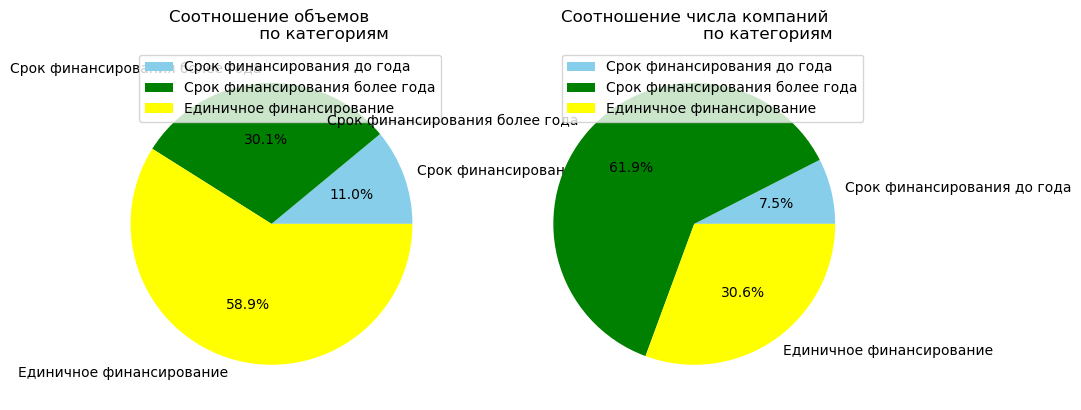

In [32]:
# Соединим полученные таблицы groupby_category funding_total для совместной визуализации
merge_df=pd.concat([groupby_category,funding_total],axis=1)

# Строим графики
merge_df.plot(kind='pie',
                   subplots=True,
                     title=["""Соотношение объемов 
                     по категориям """,
                            """Соотношение числа компаний
                            по категориям"""],
                     legend=True,
                     colors=['skyblue','green','yellow'],
                     autopct='%.1f%%',
                     ylabel='',
                      figsize=(10,20)
                     )
plt.labels=True
plt.show()

Итак, 30% всех компаний финансируют более года и формируют 62% общего объема привлеченных инвестиций. Большая часть компаний (58%) произвела разовое финансирование - это может указывать на то, что такие стартапы не добились успеха, т.к. не пошли дальше одного раунда (за исключением случаем, когда стартап был сразу выкуплен). Категория компаний, закончивших финансирование в течение года, имеет наименьший вклад - 7,5%.

### Выделение средних и нишевых сегментов рынка

Компании указывают свой сегмент рынка в столбце market. Рассчитаем, как часто в датасете встречается каждый из сегментов. 

Сегменты, к которым относится более 120 компаний, отнесем к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесем к средним, а сегменты до 35 компаний отнесем к нишевым.

Дополнительно посчитаем объем инвестиций для каждой категории

In [33]:
# Посчитаем количество компаний по сегментам
companies_by_market=invest_df.groupby('market')['name'].count().reset_index()
companies_by_market.columns=['market','count']

# Напишем функцию, позволющую отнести каждую компанию к трем категориям сегментов
def segments(row):
    if row['count']>120:
        return 'Массовый сегмент'
    elif row['count']>=35:
        return 'Средний сегмент'
    elif row['count']<35:
        return 'Нишевый сегмент'
    else:
        return row['count']

# Применим функцию к датафрейму companies_by_market
companies_by_market['category_of_market']=companies_by_market.apply(segments,axis=1)

# Посмотрим на результат
companies_by_market

,market,count,category_of_market
0,3d,2,Нишевый сегмент
1,3d printing,3,Нишевый сегмент
2,ad targeting,1,Нишевый сегмент
3,advertising,1107,Массовый сегмент
4,advertising networks,1,Нишевый сегмент
...,...,...,...
389,weddings,2,Нишевый сегмент
390,wholesale,2,Нишевый сегмент
391,wine and spirits,2,Нишевый сегмент
392,wireless,64,Средний сегмент


In [34]:
# Посчитаем количество сегментов по категориям
count_segments=companies_by_market.groupby('category_of_market')['market'].count()

count_segments

category_of_market
Массовый сегмент     48
Нишевый сегмент     289
Средний сегмент      57
Name: market, dtype: int64

In [35]:
# Посчитаем количество компаний в каждом сегменте
group_by_segment=companies_by_market.groupby('category_of_market')['count'].sum()

group_by_segment

category_of_market
Массовый сегмент    33732
Нишевый сегмент       830
Средний сегмент      3841
Name: count, dtype: int64

Построим два графика: распределение количества компаний по категориям и количество сегментов по категорями

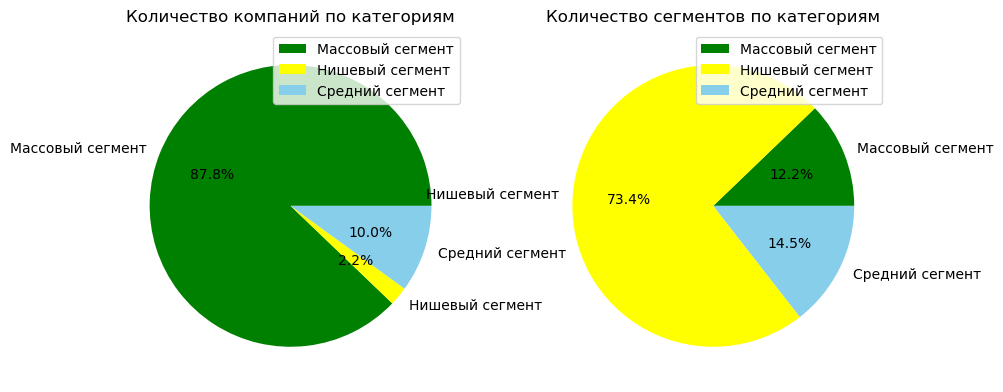

In [36]:
# Объединим две таблицы в одну
merge_for_visual=pd.concat([group_by_segment,count_segments],axis=1)

# Строим два графика
merge_for_visual.plot(kind='pie',
                      subplots=True,
                     title = ['Количество компаний по категориям',
                              'Количество сегментов по категориям'],
                     legend=True,
                     colors=['green','yellow','skyblue'],
                     autopct='%.1f%%',
                     ylabel='',
                     figsize=(10,20))
plt.show()

Таким образом, большинство компаний действует в массовых отраслях - почти 88% от всех компаний, однако число таких отраслей всего 12,2%, в то время как число нишевых сегментов 73,4% при 2,2% всех компаний. Такая асимметрия может описать рынок стартапов следующим образом: на рынке действуют отрасли-гиганты, которые характеризуются зрелостью и высокой конкуренцией, новые же стартапы стараются занять нетронутую нишу, которая никем не заполнена, поэтому так много новых отраслей с таким небольшим количеством участников.

Для дальнейшей работы оставим только массовые сегменты в поле market, нишевые и средние сегменты заменим значениями niche и mid

In [37]:
# Добавим обозначения категорий в исходных датафрейм
invest_df=invest_df.merge(companies_by_market[['market','category_of_market']],on='market',how='left')

# Заменим значения для нишевых и средних сегментов значениями niche и mid
def replace_market(row):
    if row['category_of_market']=='Нишевый сегмент':
        return 'niche'
    if row['category_of_market']=='Средний сегмент':
        return 'mid'
    else:
        return row['market']

invest_df['market']=invest_df.apply(replace_market,axis=1)


In [38]:
# Проверим количество нишевых и средних отраслей в поле market после замены
invest_df[(invest_df['market']=='niche') | (invest_df['market']=='mid')]['market'].count()

np.int64(4671)

4671 - ровно столько компаний функционируют в нишевых и средних сегментах согласно ранее сделанным подсчетам

В результате инжиниринга данных 
- проведена категоризация компаний по срокам финансирования: основную долю общего объема инвестиций (62%) внесли компании, инвестирующие более одного года при их количестве около 30% от общего числа; наименьший вклад (7,5%) приходится на компании, закончивших свое финансирование в течение года;
- проведена категоризация отраслей: на рынке существуют крупные отрасли с высокой конкуренций, однако таких отраслей мало, новые же технологии и проекты стараются занимать незаполненные сферы, поэтому нишевых отраслей более 73% от всех сегментов, но содержат они в совокупности лишь 2,2% всех компаний 

## Работа с выбросами и анализ

### Анализируем и помечаем выбросы в каждом из сегментов

**По предобработанному столбцу `funding_total_usd` графическим образом оценим, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся**

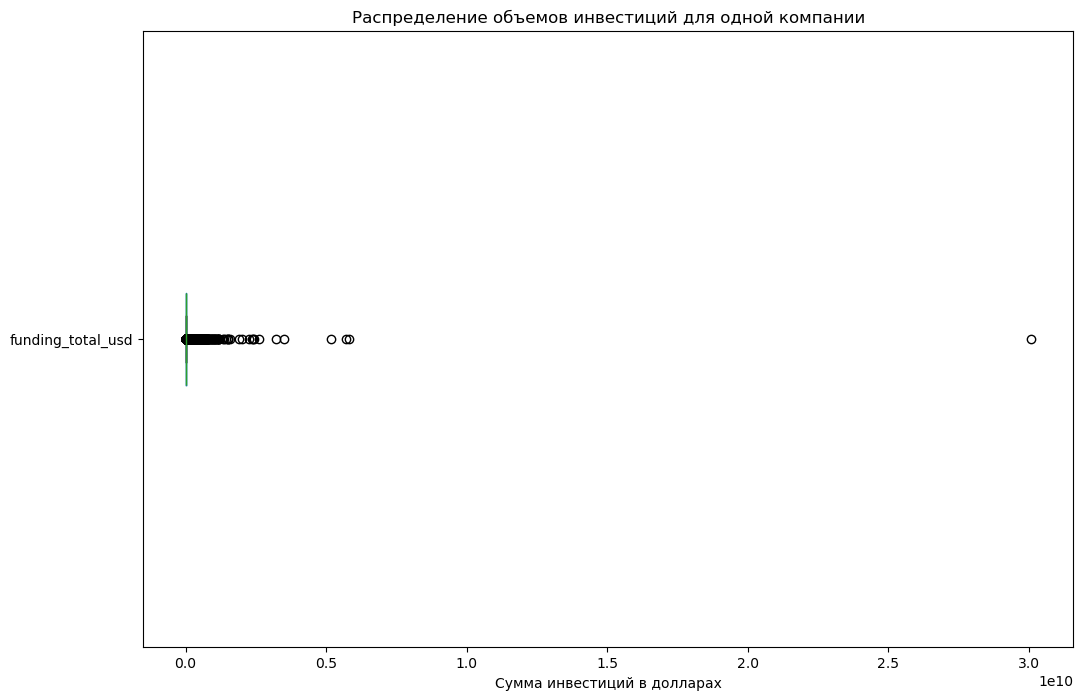

In [39]:
# Посмотрим диаграмму размаха общего вида
boxplot=invest_df.boxplot(column='funding_total_usd',
                         grid=False,
                         figsize=(12,8),
                         vert=False)

boxplot.set_title('Распределение объемов инвестиций для одной компании')
boxplot.set_xlabel('Сумма инвестиций в долларах')
plt.show()

По диаграмме видно, что в поле присутствуют выбросы, начиная примерно с 500 млн. долларов (0,05 по оси х). Однако, учитывая контекст данных, такие суммы инвестирования нельзя отрицать и считать ошибочными. Чтобы лучше увидеть типичные значения для данного столбца, изменим масштаб.

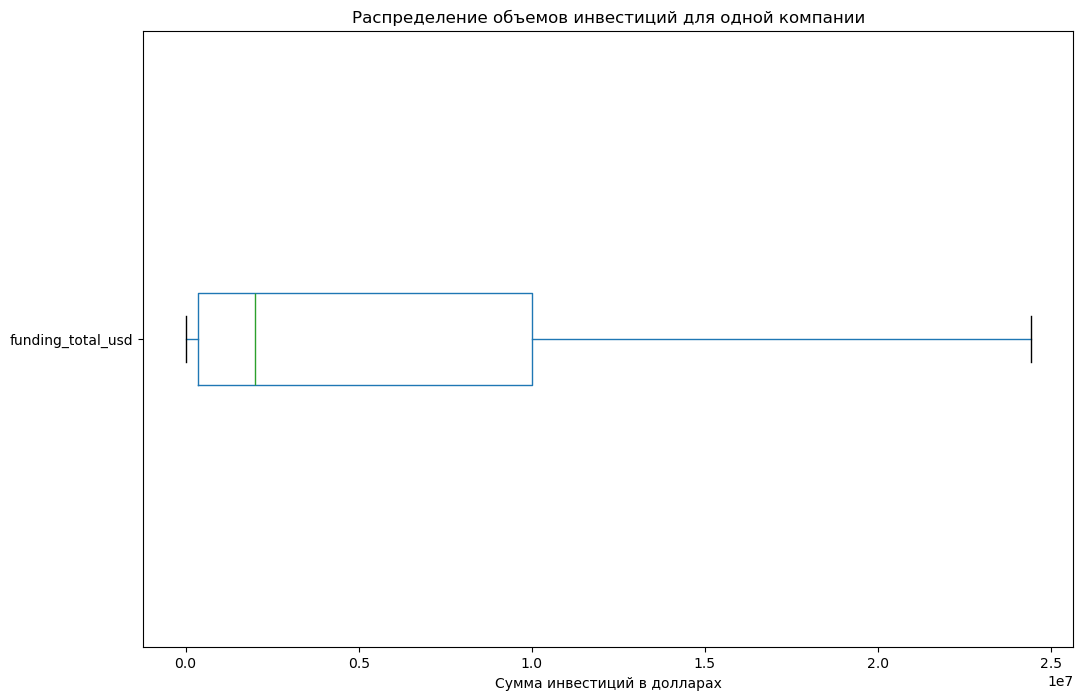

In [40]:
# Построим диаграмму размаха, отбросив выбросы
boxplot=invest_df.boxplot(column='funding_total_usd',
                          grid=False,
                          vert=False,
                          figsize=(12,8),
                          showfliers=False
                         )
boxplot.set_title('Распределение объемов инвестиций для одной компании')
boxplot.set_xlabel('Сумма инвестиций в долларах')
plt.show()

Итак, по графику видно, что:
- основной объем инвестиций на одну компанию находится в пределах 10 млн долларов;
- максимальное значение без учетов выбросов равно примерно 24-м млн;
- минимальное значение близко или равно 0;
- медиана равна примерно 1,8-2 млн долларов.

**Далее определим компании с аномальным объёмом общего финансирования внутри каждого сегмента и найдем топ сегментов рынка с наибольшей долей компаний, получивших аномальное финансирование**

In [41]:
invest_df.isna().sum()

name                                      1
homepage_url                           2314
category_list                          2503
market                                 2503
funding_total_usd                         0
status                                 1105
country_code                           3819
state_code                            15288
region                                 3819
city                                   4505
funding_rounds                            0
participants                          13576
founded_at                             8707
founded_month                          8772
founded_quarter                        8772
founded_year                           8706
first_funding_at                          2
mid_funding_at                            1
last_funding_at                           0
seed                                      0
venture                                   0
equity_crowdfunding                       0
undisclosed                     

In [42]:
# Напишем функцию, которая для каждого сегмента возвращает маску True/False: True — если компания с аномальным финансированием
def find_outliers_iqr(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    return group > upper_bound

# Отбросим строки с выбросами в поле market для корректной работы функции
invest_df=invest_df[~invest_df['market'].isna()]

# Применяем функцию к каждому сегменту
invest_df['is_outlier'] = invest_df.groupby('market')['funding_total_usd'].transform(find_outliers_iqr)

# Считаем статистику по сегментам
outlier_stats = invest_df.groupby('market').agg(
    total_companies=('name', 'count'),
    outlier_count=('is_outlier', 'sum'), # количество аномалий
    outlier_share=('is_outlier', 'mean')  # доля аномалий
).reset_index()

# Сортируем и выводим топ-10
top_outlier_segments = outlier_stats.sort_values('outlier_share', ascending=False).head(10)

top_outlier_segments

,market,total_companies,outlier_count,outlier_share
36,real estate,279,48,0.172043
14,entertainment,150,25,0.166667
8,consulting,349,58,0.166189
38,search,291,48,0.164948
7,cloud computing,152,25,0.164474
37,saas,272,44,0.161765
34,photography,204,33,0.161765
46,technology,238,38,0.159664
48,video,188,30,0.159574
32,niche,830,132,0.159036


Итак, наибольшее количество компаний, получивший аномальное финансирование, относятся к сегментам (по убыванию числа компаний): недвижимость (real estate), развлечения (entertainment), консалтинг - доля компаний с выбросами в инвестициях в таких секторах в среднем чуть более 16%.

### Определяем границы рассматриваемого периода, отбрасываем аномалии

**Проверим по датасету полноту данных за 2014 год**

In [43]:
# Отфильтруем датафрейм по дате последнего финансирования
year_2014=invest_df[invest_df['last_funding_at'].dt.year==2014]
    
# Посчитаем долю пропусков в столбцах
year_2014.isna().mean()

name                                  0.000000
homepage_url                          0.030515
category_list                         0.000000
market                                0.000000
funding_total_usd                     0.000000
status                                0.023249
country_code                          0.091726
state_code                            0.348833
region                                0.091726
city                                  0.110253
funding_rounds                        0.000000
participants                          0.614658
founded_at                            0.174371
founded_month                         0.176278
founded_quarter                       0.176278
founded_year                          0.174280
first_funding_at                      0.000091
mid_funding_at                        0.000091
last_funding_at                       0.000000
seed                                  0.000000
venture                               0.000000
equity_crowdf

In [44]:
# Дополнительно выведем последнюю дату финансирования
year_2014['last_funding_at'].max()

Timestamp('2014-12-31 00:00:00')

Итак, за 2014 год в датафрейме отсутствуют пропуски в включевых для анализа полях `name`, `funding_total_usd`, `funding_rounds`, а дата последнего финансирования - конец 2014 года. Таким образом, можно утверждать, что данные за 2014 в достаточной степени полны, и 2014 год будет считаться верхней границей периода для анализа

In [45]:
invest_df['is_outlier']

0         True
2        False
3        False
4        False
6         True
         ...  
40895    False
40896    False
40897    False
40903    False
40906    False
Name: is_outlier, Length: 38404, dtype: bool

**Исключим из датасета компании, которые получили аномальное финансирование**


In [46]:
# Отфильтруем датасет по списку с именами компаний, получивших аномальное финансирование
df=invest_df[invest_df['is_outlier']==False].copy()

# Оценим объем датафрейма
df.shape

(33533, 43)

**На основе столбцов `mid_funding_at` и `funding_rounds` оставим в датасете данные только о тех компаниях, которые должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.**

In [47]:
# Создадим столбец с годом на основе поля mid_funding_at
df['funding_year']= df['mid_funding_at'].dt.year

# Сгруппируем данные по годам
group_df=df.groupby('funding_year')['funding_rounds'].sum().reset_index()

# Создадим список годов, когда было зафиксировано 50 или более раундов финансирования
rounds_50_df=group_df[group_df['funding_rounds']>=50]

invest_years=list(rounds_50_df['funding_year'])

# Оставим в датафрейме данные только для этих годов
df=df[(df['mid_funding_at'].notna()) & (df['mid_funding_at'].dt.year.isin(invest_years))]

# Проверим, в какие годы было зафиксировано 50 и более раундов
sorted(df['funding_year'].unique())

[np.float64(2000.0),
 np.float64(2001.0),
 np.float64(2002.0),
 np.float64(2003.0),
 np.float64(2004.0),
 np.float64(2005.0),
 np.float64(2006.0),
 np.float64(2007.0),
 np.float64(2008.0),
 np.float64(2009.0),
 np.float64(2010.0),
 np.float64(2011.0),
 np.float64(2012.0),
 np.float64(2013.0),
 np.float64(2014.0)]

Итак, в рабочем датафрейме df были отброшены компании, получившие аномальное финансирование, а также отфильтрованы по дате те строки, в которых дата среднего по времени финансирования была в годы, когда было зафиксировано 50 или менее раундов финансирования (по итогу: с 2000 по 2014 гг).

### Анализ типов финансирования по объёму и популярности

**Построим график, который покажет, какие типы финансирования в сумме привлекли больше всего денег**. 

Типы финансирования представлены в виде столбцов: `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.

In [48]:
# Напишем функцию, которая создаст датафрейм с типами финансирования и суммами
def sum_values(df):
    list_sum=[]
    list_name=[]
    for i in ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 
              'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 
              'post_ipo_debt', 'secondary_market','product_crowdfunding']:
        list_sum.append(df[i].sum())
        list_name.append(i)
    invest_types=pd.DataFrame({'investment_type':list_name,
                               'investment_sum':list_sum
                             })
    return invest_types

# Применим функицю к датафрейму
invest_types_df = sum_values(df).sort_values(by='investment_sum',ascending=False)

# Добавим долю от общей суммы инвестирования
invest_types_df['investment_share']=invest_types_df['investment_sum']/invest_types_df['investment_sum'].sum()

# Посмотрим на результат
invest_types_df

,investment_type,investment_sum,investment_share
1,venture,1.281119e+11,0.802382
0,seed,9.110755e+09,0.057062
5,debt_financing,8.010603e+09,0.050171
8,private_equity,4.810806e+09,0.030131
6,angel,2.440582e+09,0.015286
3,undisclosed,2.034127e+09,0.012740
9,post_ipo_equity,1.942102e+09,0.012164
7,grant,1.913027e+09,0.011982
4,convertible_note,5.504268e+08,0.003447
10,post_ipo_debt,2.867183e+08,0.001796


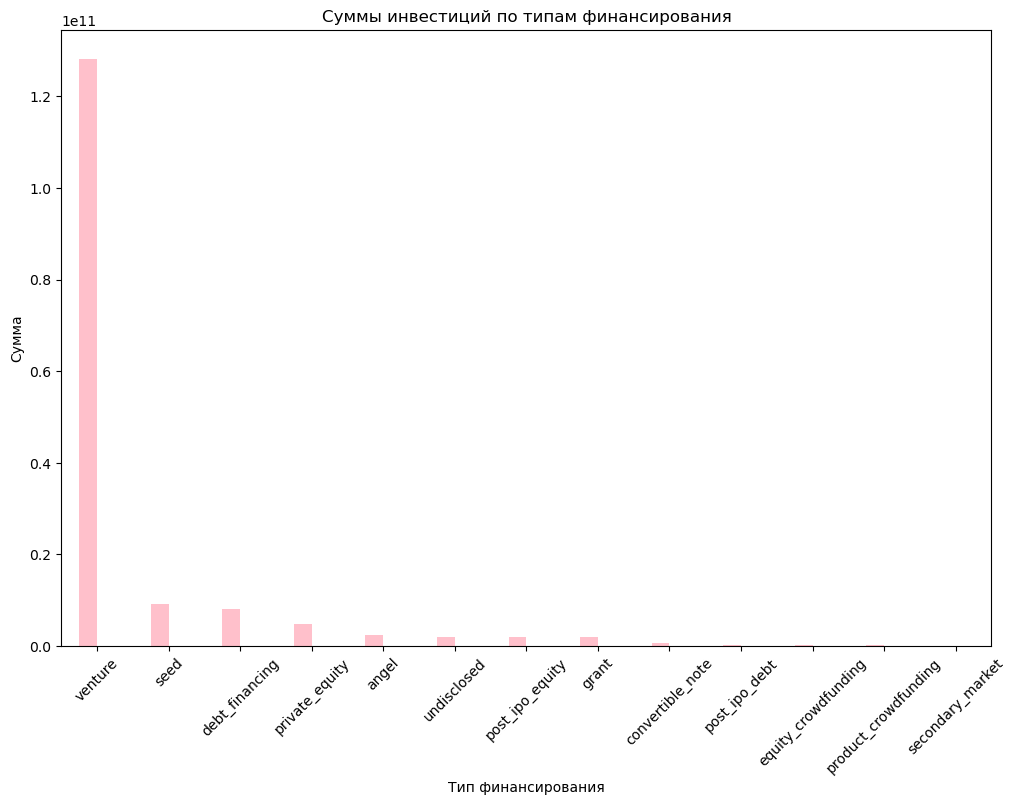

In [49]:
# Визуализируем результат
invest_types_df.plot(kind='bar',
                    title='Суммы инвестиций по типам финансирования',
                    xlabel='Тип финансирования',
                    ylabel='Сумма',
                    x='investment_type',
                    figsize=(12,8),
                    rot=45,
                    color='pink',
                    legend=False                              
                    )

plt.show()

Итак, с отрывом лидирует сумма венчурных инвестиций - почти 80% от всего объема.

**Построим график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями**

In [50]:
# Заменим нулевые значения пропусками в каждом поле с типами финансирования
for i in ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 
              'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 
              'post_ipo_debt', 'secondary_market','product_crowdfunding']:
    df[i]=df[i].replace(0,pd.NA)

# Посчитаем количество заполненных значений в каждом поле
popular_types=df[['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 
              'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 
              'post_ipo_debt', 'secondary_market','product_crowdfunding']].notna().sum().sort_values(ascending=False)

# добавим столбец с долями от общего количества
popular_types=popular_types.reset_index()

popular_types['share']=popular_types[0]/len(df)

popular_types.columns=['invest_type','count','share']
# Посмотрим на результат
popular_types

,invest_type,count,share
0,venture,18139,0.541899
1,seed,12349,0.368924
2,debt_financing,3097,0.092522
3,angel,2863,0.085532
4,grant,918,0.027425
5,undisclosed,741,0.022137
6,private_equity,618,0.018463
7,convertible_note,501,0.014967
8,equity_crowdfunding,471,0.014071
9,product_crowdfunding,195,0.005826


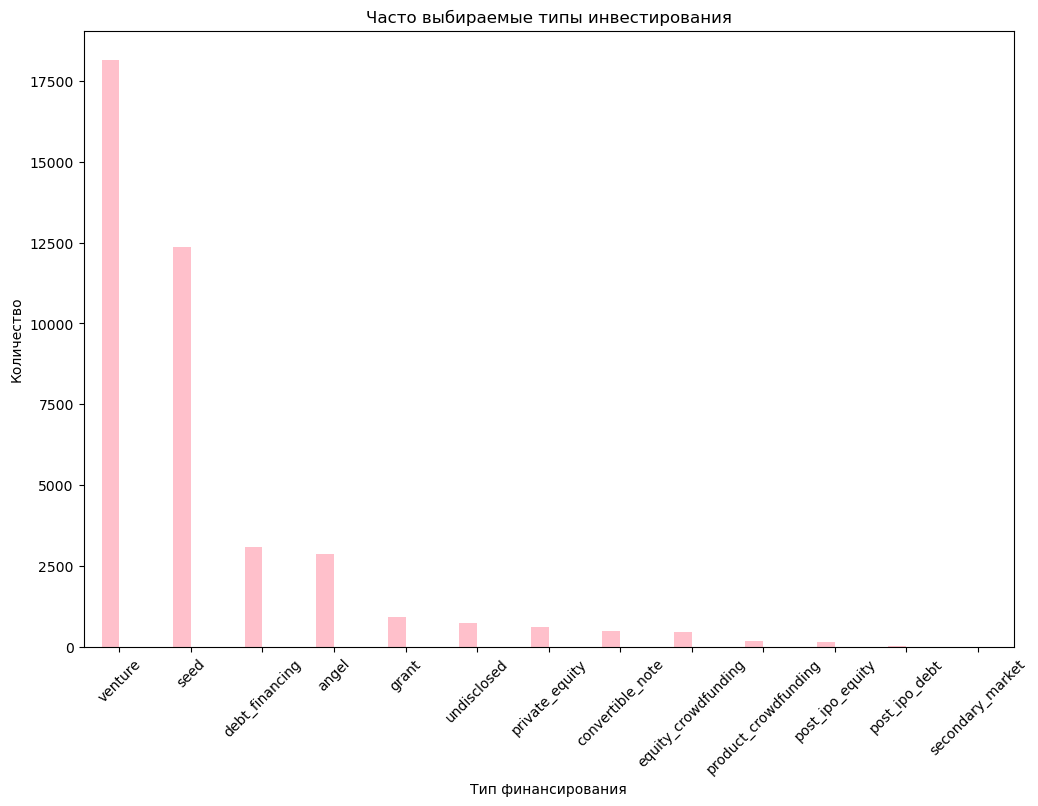

In [51]:
# Визуализируем результат
popular_types.plot(kind='bar',
                    title='Часто выбираемые типы инвестирования',
                    xlabel='Тип финансирования',
                    ylabel='Количество',
                    x='invest_type',
                    figsize=(12,8),
                    rot=45,
                    color='pink',
                    legend=False                              
                    )

plt.show()

По диаграмме видно, что компании чаще всего выбирает венчурные ивестиции (почти 53% всех инвестиций), на втором месте инвестиции на посевной стадии (почти 38%). Остальные типы финансирования менее 10% каждый.

Анализ графиков с типами финансирования показал, что
- `seed` - инвестиции на посевной стадии часто используются компаниями (37% от общего числа), при этом доля от суммарного объема инвестиций для данного типа составляет менее 8%;
- `angel` - на инвестиции от бизнес-ангелов приходится всего 2% от общего количества финансирований, при этом доля от суммарного объема инвестиций составляет 8,4%;
- `debt_financing` - долговое финансирование выбирается компаниями довольно редко (около 8,6%), при этом на данный тип приходится 8,6% от общего объема инвестиций.

**Построим график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета `returns_df`**

In [52]:
# Воспользуемся ранее написанной пользовательской функцией sum_values()
sum_returns=sum_values(returns_df).sort_values(by='investment_sum',ascending=False)

# Добавим долю от общей суммы инвестирования
sum_returns['investment_share']=sum_returns['investment_sum']/sum_returns['investment_sum'].sum()

# Посмотрим на результат
sum_returns

,investment_type,investment_sum,investment_share
1,venture,40578.62,0.740961
5,debt_financing,4734.85,0.086458
8,private_equity,3587.33,0.065504
0,seed,2382.24,0.043499
6,angel,1509.23,0.027558
9,post_ipo_equity,1104.96,0.020176
3,undisclosed,730.88,0.013346
10,post_ipo_debt,91.03,0.001662
4,convertible_note,34.79,0.000635
11,secondary_market,5.20,0.000095


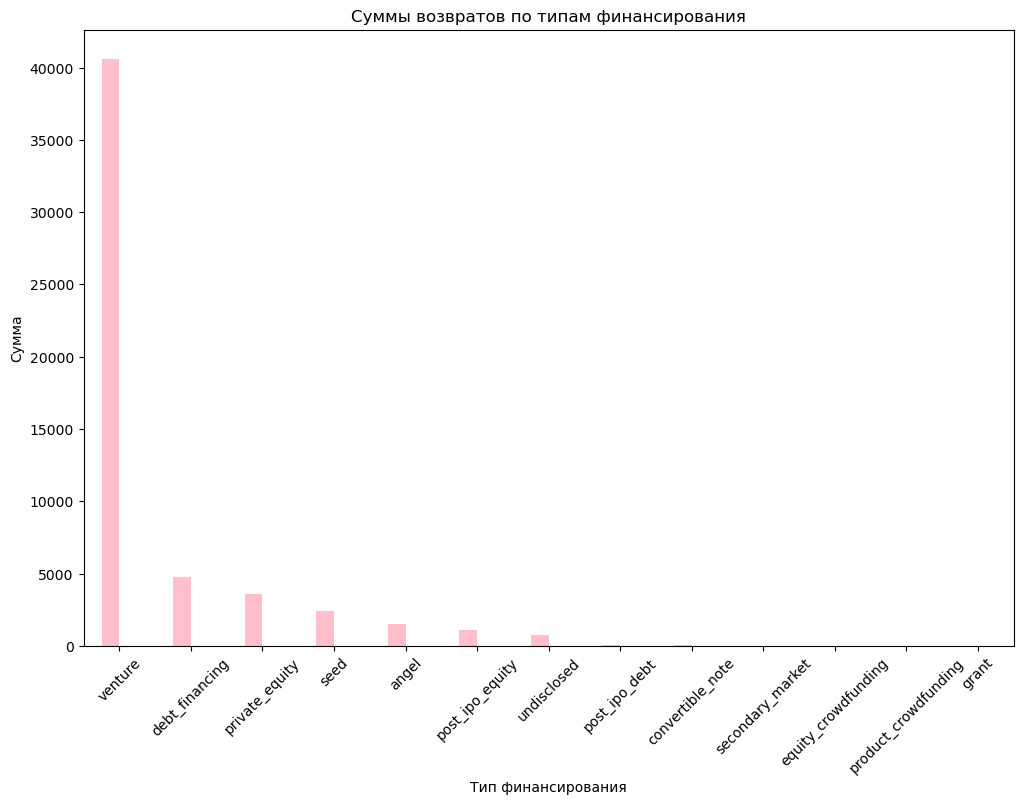

In [53]:
# Визуализируем результат
sum_returns.plot(kind='bar',
                    title='Суммы возвратов по типам финансирования',
                    xlabel='Тип финансирования',
                    ylabel='Сумма',
                    x='investment_type',
                    figsize=(12,8),
                    rot=45,
                    color='pink',
                    legend=False                              
                    )

plt.show()

По графику видно, что наибольший объем возвратов приходится на венчурное финансирование (74% от общей суммы возвратов).
На втором месте - сумма долгового финансирования (8,6%), на третьем - инвестиции от частных вложений (6,5%)

## Анализ динамики 

### Динамика предоставления финансирования по годам

**Используя столбцы funding_total_usd и funding_rounds, рассчитаем для каждой компании средний объём одного раунда финансирования.**

In [54]:
# Посчитаем общее число раундов и объем инвестиций по годам
groupby_year_df=df.groupby('funding_year')[['funding_total_usd','funding_rounds']].sum()

# Найдем средний объем одного раунда финансирования
groupby_year_df['average_funding']=(groupby_year_df['funding_total_usd']/groupby_year_df['funding_rounds']).round(2)

**На основе получившейся таблицы построим графики, отражающие:**

- динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

- динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

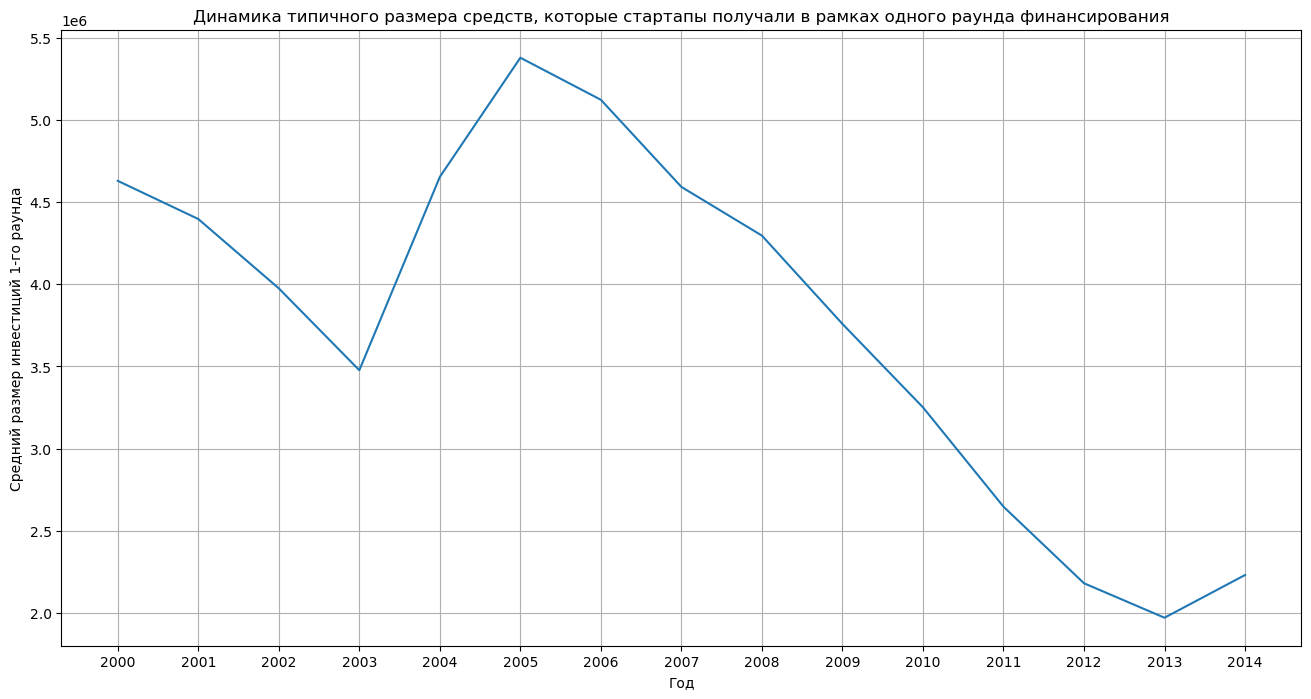

In [55]:
# Визуализируем динамику среднего размера финансирования по годам
ax=groupby_year_df.plot(kind='line',
                    y='average_funding',
                    title='Динамика типичного размера средств, которые стартапы получали в рамках одного раунда финансирования',
                    xlabel='Год',
                    ylabel='Средний размер инвестиций 1-го раунда',
                    figsize=(16,8),
                    legend=False,
                    grid=True)
ax.set_xticks(groupby_year_df.index)
plt.show()

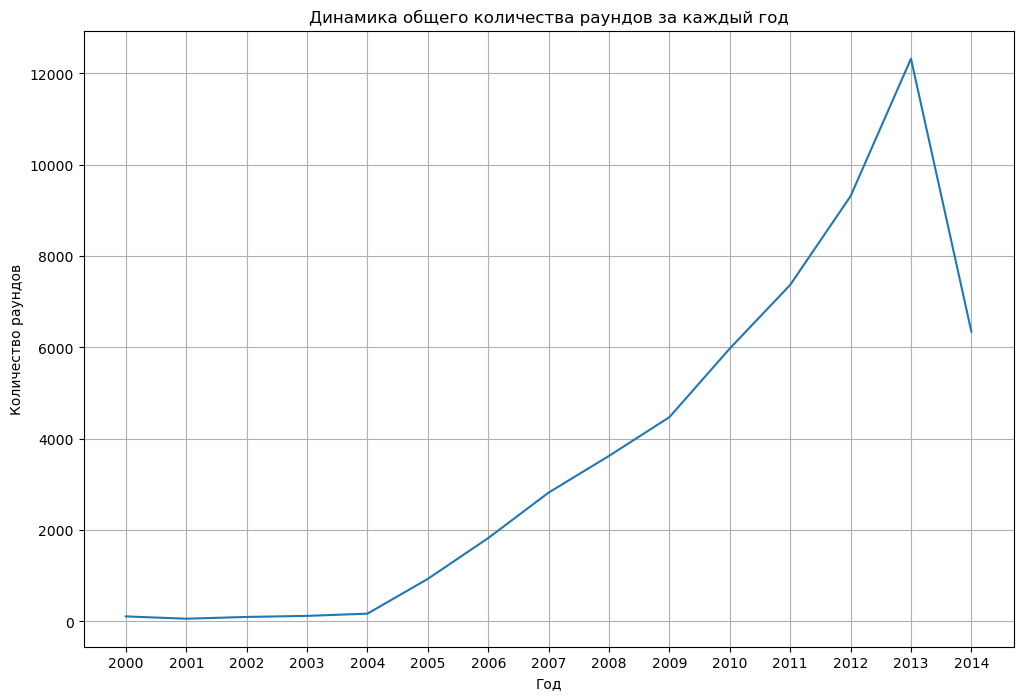

In [56]:
# Визуализируем динамику общего количества раундов за каждый год
ax=groupby_year_df.plot(kind='line',
                    y='funding_rounds',
                    title='Динамика общего количества раундов за каждый год',
                    xlabel='Год',
                    ylabel='Количество раундов',
                    figsize=(12,8),
                    legend=False,
                    grid=True)
ax.set_xticks(groupby_year_df.index)
plt.show()

Исследуя графики, можно сделать следующие выводы:
- максимальный средний объем инвестиций на 1 раунд зафиксирован в 2005 году; после 2005 года видно стабильное снижение среднего значения; минимум приходится на 2013 год.
- в 2014 году начался рост типичного объема финансирования на 1 раунд после пикового падения в 2013 и в то же время начался спад числа раундов - что вполне закономерно: число раундов уменьшилось, следовательно, средний объем средств на 1 раунд увеличился.

### Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

**Составим сводную таблицу, в которой указывается суммарный размер общего финансирования funding_total_usd по годам и сегментам рынка.**

In [57]:
pivot_dynamics=df.pivot_table(index='market',
                        columns='funding_year',
                        values='funding_total_usd',
                        aggfunc='sum'
)

pivot_dynamics

funding_year,2000.0,2001.0,2002.0,2003.0,2004.0,2005.0,2006.0,2007.0,2008.0,2009.0,2010.0,2011.0,2012.0,2013.0,2014.0
market,,,,,,,,,,,,,,,
advertising,14470000.0,8778321.0,24500000.0,10500000.0,6000000.0,127196022.0,2.992995e+08,5.567043e+08,6.226735e+08,5.634460e+08,6.316179e+08,4.107307e+08,5.211370e+08,5.249151e+08,2.077923e+08
analytics,14822803.0,NaN,7500000.0,3840000.0,3000000.0,79014044.0,1.397013e+08,9.882900e+07,2.080778e+08,1.409493e+08,2.537399e+08,4.433334e+08,5.392143e+08,6.228214e+08,1.514616e+08
apps,NaN,NaN,NaN,NaN,NaN,NaN,1.310600e+06,NaN,4.300000e+06,7.219000e+06,6.123779e+06,1.837407e+07,3.260112e+07,2.886862e+07,6.623773e+07
automotive,NaN,NaN,NaN,4530000.0,NaN,22500000.0,1.266000e+07,3.771260e+07,5.947864e+07,2.080031e+07,1.769692e+07,7.645216e+07,3.555768e+07,1.175725e+08,6.903416e+07
big data,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.780000e+06,2.452515e+06,5.973750e+05,3.923330e+07,6.036916e+07,8.641334e+07,7.869892e+07,7.923260e+07
biotechnology,NaN,NaN,NaN,85531178.0,97184859.0,480063583.0,9.035005e+08,1.704078e+09,1.716033e+09,3.915901e+09,4.894500e+09,4.967552e+09,4.931139e+09,5.694270e+09,2.509639e+09
clean technology,NaN,NaN,34390435.0,50352939.0,50427954.0,19420000.0,1.314739e+08,7.497112e+08,3.165808e+09,1.963503e+09,1.604429e+09,1.545603e+09,9.580112e+08,1.203061e+09,6.886868e+08
cloud computing,11500000.0,NaN,NaN,NaN,NaN,NaN,9.951809e+06,2.035434e+07,4.437500e+07,5.222372e+07,8.525538e+06,7.315140e+07,7.442158e+07,8.484678e+07,7.344086e+07
consulting,4500000.0,NaN,NaN,NaN,NaN,44862000.0,2.396555e+07,7.034634e+07,1.906108e+07,6.271516e+07,8.126488e+07,4.341340e+07,6.592276e+07,9.332132e+07,5.429802e+07


Отберем из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013, исключая средние и нишевые сегменты

In [58]:
# Уибраем нишевый и средний сегмент
filtered_tabel=pivot_dynamics = pivot_dynamics.loc[~pivot_dynamics.index.isin(['niche', 'mid'])]

# Фильтруем по сегментам: оставим те, у которых размер финансирования в 2014 году больше, чем в 2013
filtered_tabel=filtered_tabel[filtered_tabel[2014]>filtered_tabel[2013]]

filtered_tabel

funding_year,2000.0,2001.0,2002.0,2003.0,2004.0,2005.0,2006.0,2007.0,2008.0,2009.0,2010.0,2011.0,2012.0,2013.0,2014.0
market,,,,,,,,,,,,,,,
apps,NaN,NaN,NaN,NaN,NaN,NaN,1310600.0,NaN,4300000.0,7219000.0,6123779.0,18374071.0,32601125.0,28868621.0,66237730.0
big data,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7780000.0,2452515.0,597375.0,39233297.0,60369158.0,86413341.0,78698922.0,79232600.0
design,NaN,NaN,NaN,NaN,NaN,9300000.0,707000.0,10800000.0,5944302.0,2150144.0,17239975.0,8899967.0,39630692.0,60958835.0,68988516.0
internet,10000000.0,NaN,1100000.0,NaN,10500000.0,1775000.0,5000.0,4495379.0,23412964.0,38195773.0,36657500.0,36859032.0,28288685.0,69732096.0,117830756.0
manufacturing,56659310.0,2368582.0,NaN,4269608.0,3000000.0,61770000.0,163957751.0,147726051.0,173054260.0,422862531.0,244329661.0,561639285.0,522205168.0,393936634.0,416332314.0
medical,24000000.0,NaN,NaN,NaN,NaN,11090000.0,20250000.0,2100000.0,28812744.0,11566200.0,25590338.0,28540962.0,44039600.0,64469424.0,175236064.0
real estate,2500000.0,NaN,5275000.0,6292200.0,NaN,250000.0,2080000.0,33220000.0,46613100.0,38840213.0,37344608.0,20015128.0,77320857.0,92207655.0,115567364.0
saas,NaN,NaN,2000000.0,NaN,NaN,5240000.0,4791121.0,14652595.0,27226900.0,13536585.0,32609390.0,32223749.0,49699912.0,79576613.0,92807752.0
startups,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5010387.0,460700.0,2111966.0,19654403.0,12358782.0,18080552.0,41501837.0


**Построим график изменения суммарного размера общего финансирования в каждом из отобранных сегментов по годам**

Сначала отбросим те годы, в которых отсутствует полная информация о размере инвестиций. По таблице видно, отбросить нужно все годы до 2008

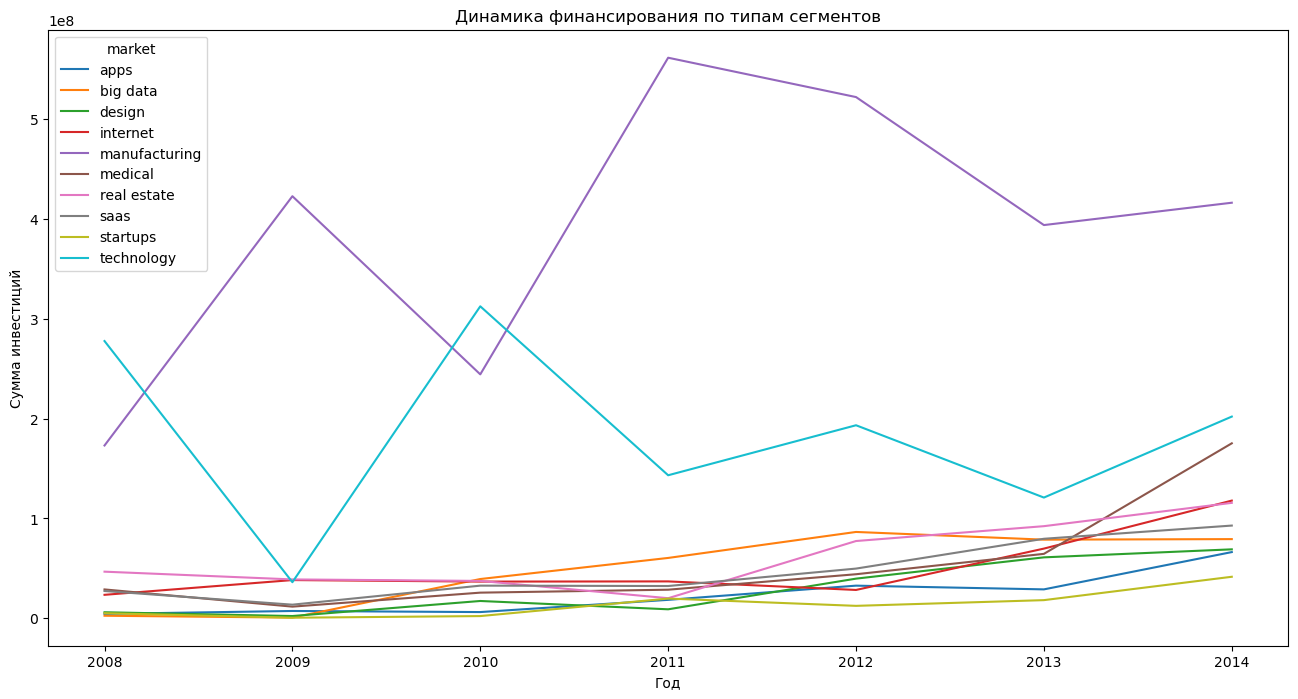

In [59]:
needed_years=[i for i in filtered_tabel.columns if i >= 2008] # список годов от 2008

tabel_for_visual = filtered_tabel[needed_years] # фильтруем сводую таблицу по годам

# Строим график, предварительно транспонировав таблицу

tabel_for_visual.T.plot(kind='line',
                     figsize=(16, 8),
                     title='Динамика финансирования по типам сегментов',
                     xlabel='Год',
                     ylabel='Сумма инвестиций'
                    )

plt.show()

- По графику явно выделяется промышленный сектор *manufacturing*, показавший резкий скачок и удерживающий наибольший объем инвестиций;
- Вторым по стоимости сектором является технологический сегмент с синусоидальной динамикой;
- Секторы *real_estate* и *design* стабильно растут с 2011 года;
- У интернет-сегмента *internet* виден активный рост с 2012 года;
- Сектор *saas* медленно, но стабильно растет с 2009 года;
- *startups*, *apps*, *medical* растут с 2013 года;
- Все отрасли, кроме *medical*, *technology*, *manufactoring* привлекали за рассматриваемый период не более 100 млн долларов в год.

### Годовая динамика доли возвращённых средств по типам финансирования

Определим, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Для каждого года и каждого вида финансирования рассчитаем нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, заменим на пропуски.


In [60]:
# Создадим датафрейм с суммами финансирования видам и годам
investment = df[['funding_year','seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 
              'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 
              'post_ipo_debt', 'secondary_market','product_crowdfunding']].set_index('funding_year')

# Сгруппируем данные по годам
investment=investment.groupby(level='funding_year').sum()

# Перед делением добавим небольшое число ко всем значениям датафрейма investment 
investment=(investment+1/1000000).round(6)

# Переведем значения датафрейма returns_df в доллары, умножив на миллион
returns_df=returns_df*1000000

# Разделим значения датафрейма returns_df на значения investment
share_returns=returns_df/investment

# Посмотрим на результат
share_returns

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,0.998557,0.169857,0.0,0.697042,0.0,0.618571,0.266956,0.0,0.0,0.271069,0.0,0.025911,0.0
2001,1.079592,0.111534,0.0,0.587483,0.006667,1.740838,1.18,0.0,0.0,460000000000.0,0.0,460000000000.0,0.0
2002,0.629707,0.68282,0.0,0.608878,20000000000.0,0.223388,1.136667,0.0,0.201333,1.133333,0.0,60000000000.0,0.0
2003,0.537748,0.63376,0.0,0.914397,10000000000.0,1.038095,0.60572,0.0,1620000000000.0,2110000000000.0,0.0,80000000000.0,0.0
2004,0.556155,0.842401,0.0,0.566719,10000000000.0,0.470215,0.833504,0.0,2190000000000.0,3380000000000.0,0.0,550000000000.0,0.0
2005,0.777562,0.548927,0.0,1.529281,20000000000.0,0.344964,0.509894,0.0,0.48,0.731857,0.0,50000000000.0,0.0
2006,0.934111,0.345073,190000000000.0,0.803434,0.166318,0.829083,0.675999,0.0,0.947881,20580000000000.0,0.0,120000000000.0,0.0
2007,0.368202,0.297975,10000000000.0,0.504971,0.228097,0.602488,0.825843,0.0,0.590113,2.03,0.0,570000000000.0,0.0
2008,0.301587,0.191301,30000000000.0,0.348874,0.069845,0.930676,0.414156,0.0,0.679925,2.341111,0.0,470000000000.0,0.0


Можно увидеть аномалии в сводной таблице: из-за того что в знаменателе находились значения меньше 1, в итогой таблице появились слишком большие числа. Если сумма инвестирования на несколько прядков меньше, чем сумма возврата, мы можем считать, что в одном из датасетов допущена ошибка. Заменим такие значения пропусками.

In [61]:
# Избавимся от аномалий
share_returns=share_returns[share_returns<100]

In [62]:
share_returns

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,0.998557,0.169857,0.0,0.697042,0.0,0.618571,0.266956,0.0,0.0,0.271069,0.0,0.025911,0.0
2001,1.079592,0.111534,0.0,0.587483,0.006667,1.740838,1.18,0.0,0.0,NaN,0.0,NaN,0.0
2002,0.629707,0.68282,0.0,0.608878,NaN,0.223388,1.136667,0.0,0.201333,1.133333,0.0,NaN,0.0
2003,0.537748,0.63376,0.0,0.914397,NaN,1.038095,0.60572,0.0,NaN,NaN,0.0,NaN,0.0
2004,0.556155,0.842401,0.0,0.566719,NaN,0.470215,0.833504,0.0,NaN,NaN,0.0,NaN,0.0
2005,0.777562,0.548927,0.0,1.529281,NaN,0.344964,0.509894,0.0,0.48,0.731857,0.0,NaN,0.0
2006,0.934111,0.345073,NaN,0.803434,0.166318,0.829083,0.675999,0.0,0.947881,NaN,0.0,NaN,0.0
2007,0.368202,0.297975,NaN,0.504971,0.228097,0.602488,0.825843,0.0,0.590113,2.03,0.0,NaN,0.0
2008,0.301587,0.191301,NaN,0.348874,0.069845,0.930676,0.414156,0.0,0.679925,2.341111,0.0,NaN,0.0


**Построим график, на котором отобразим нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.**

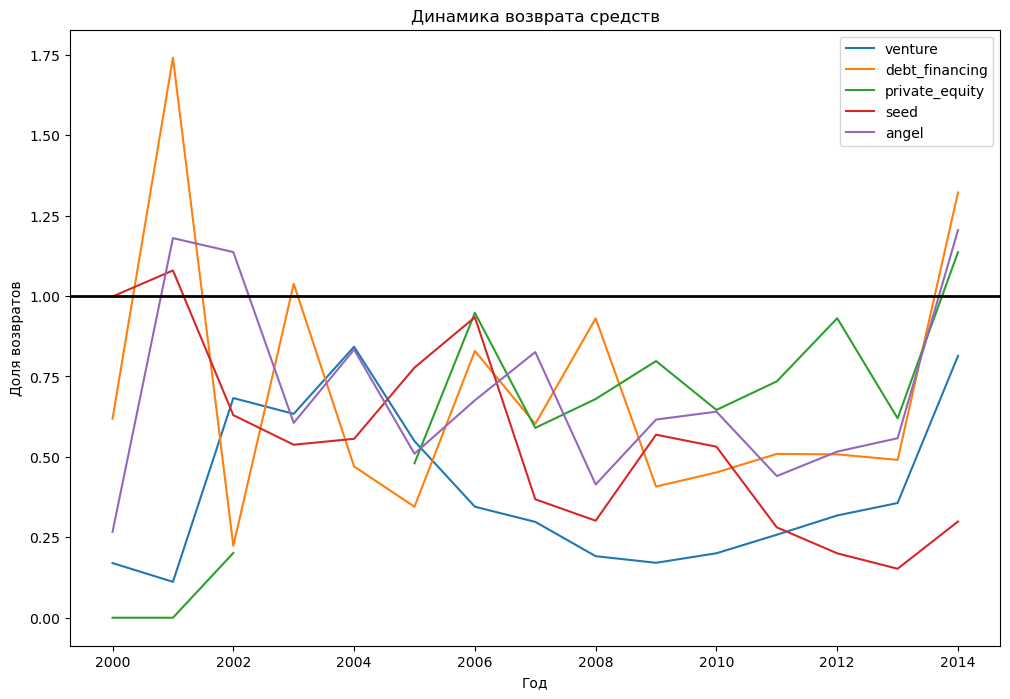

In [63]:
# Создадим датасет с нужными полями
df_for_visual=share_returns[['venture','debt_financing','private_equity','seed','angel']]

# Визуализируем динамику возвратов для данных типов финансирования
df_for_visual.plot(kind='line',
                  title='Динамика возврата средств',
                  xlabel='Год',
                  ylabel='Доля возвратов',
                  figsize=(12,8))
plt.axhline(y=1.0, color='black', linestyle='-', linewidth=2, label='Уровень 1.0')
plt.show()

По графику видно следующее:
- стабильный рост доли возвратов начиная с 2009 г. наблюдатеся только при венчурных инвестициях `venture`, однако доля возвратов останавливается на 80%;
- Рост показателя характерен для всех видов финансирования, начиная с 2013 года. Положительные доходы характерны только для полей `debt_financing`, `private_equinty`, `angel`
- Все рассматриваемые виды финансирования на протяжении всего периода с 2000 по 2014 год имеют сильно нестабильную динамику, поэтому сложно предсказать надежность того или иного типа инвестирования.

## Итоговый вывод и рекомендации

**Общий обзор по проделанной работе**

С целью выявления закономерности финансирования стартапов и оценки перспективы выхода на рынок с покупкой и развитием компаний в работу было взято два датасета: с информацией о компаниях и состоявшемся финансировании и о объемах возвратов по годам и типам финансирования. Исходные датасеты содержали более 54 тыс. строк. После предобработки данных рабочий датафрейм содержал около 40 тыс. строк данных хорошего качества.

Предобработка данных включала в себя работу с дубликатами, пропусками и типами данных.

Анализ выбросов в данных выявил около 10% аномальных значений.

Исследовательская часть была направлена на выявление наиболее перспективного сегмента финансирования.

**Выводы по исследовательской части**
- 58% всех компаний совершали разовое финансирование, формируя  30,6% общего объема инвестиций; долгосрочное финансирование менее популярно (30%), однако суммарный привлеченный объем 62%.
- рынок стартапов характеризуется небольшим количеством отраслей-гигантов (около 12% всех секторов) с высокой конкуренцией и множеством нишевых секторов (73% всех секторов) c очень малым процентом компаний-участников (2,2%);
- наиболее популярный тип финансирования - венчурный (частота - 53%, привлеченный объем средств - 80%); второй по популярности тип - инвестиции на посевной стадии (частота 38%) - собрал 7% суммарного объема инвестиций. Интересны также инвестиции от бизнес-ангелов - при частоте всего 2%  суммарный объем инвестиций составляет 8,4% и долговое финансирование (частота 8,6%, объем средств - 8,6% от общего объема инвестиций).
- по объему возвратов с отрывом лидируют венчурные инвестиции (74% от общей суммы возвратов), на втором месте долговое финансирование (8,6%).
- типичный объем финансирования на 1 раунд сильно зависит от числа раундов: чем больше раундов, тем меньше разовая сумма; с 2014 года началось уменьшение числа раундов;
- среди наиболее дорогих сегментов сильно выделяются секторы технологий и производства; остальные секторы по привлекаемым объемам инвестиций примерно равны (около 100 млн долларов на каждый сектор);
- положительная доходность наблюдается с 2014 года и характерна только для полей `debt_financing`, `private_equinty`, `angel`, однако общая динамика для данных типов инвестирования нестабильна: в разные годы наблюдаются как подъемы, так и спады;
- среди всех типов финансирования венчурное характеризуется медленным, но стабильным ростом с 2009 года с возвратами около 70-80% (на 2014 год).

**Рекомендации**

По результатам анализа, самым подходящим типом финансирования является венчурный тип: 53% частоты инвестирования, 80% объема средств, 74% возвратов от привлеченной суммы, кроме того, стабильный рост доли вовзратов с 2009 года  говорит о зрелости и достаточной надежности сегмента.

Если выбирать среди отраслей для инвестирования, то стоит выбирать те, которые не привлекают много капитала: такие секторы дорогие, имеют высокий порог входа и, следовательно, очень конкуренты. Они могут быть надежнымы для долгосрочных инвестиций, но не обязательно сверхприбыльными.

По результатам анализа можно порекомендовать более делатльно изучить текущий рынок стартапов в сфере недвижимости, интернета и приложений: данные сектоы имеет небольшой объем привлекаемых средств с отсутствием быстрой динамики роста этого показателя и невысокую конкуренцию.